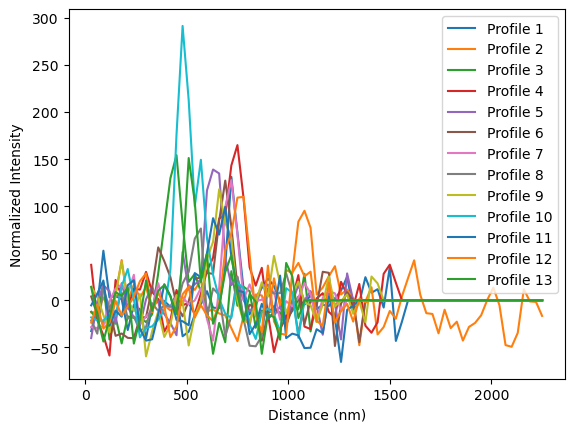

In [31]:
import csv
import numpy as np
import matplotlib.pyplot as plt

csv_file_path = 'LineProfiles75mW_3.txt'
pxSize = 30
x = []

y_values = []

# Read data from the CSV file
with open(csv_file_path, 'r') as file:
    reader = csv.reader(file, delimiter='\t')  # Assuming tab-separated values
    header = next(reader)  # Skip the first row (titles)

    for row in reader:
        x.append(int(row[0]))  # First column is x
        y_row = [float(val) for val in row[1:] if val.strip() != '']  # Convert all y-values, skip empty
        y_values.append(y_row)

# Convert to numpy arrays
x = np.array(x) * pxSize
y = np.array(y_values).T  # Transpose to shape (num_profiles, num_points)

# Plot all profiles
plt.figure()
for i in range(y.shape[0]):
    plt.plot(x, y[i], label=f'Profile {i+1}')
plt.xlabel('Distance (nm)')
plt.ylabel('Normalized Intensity')
plt.legend()
plt.show()

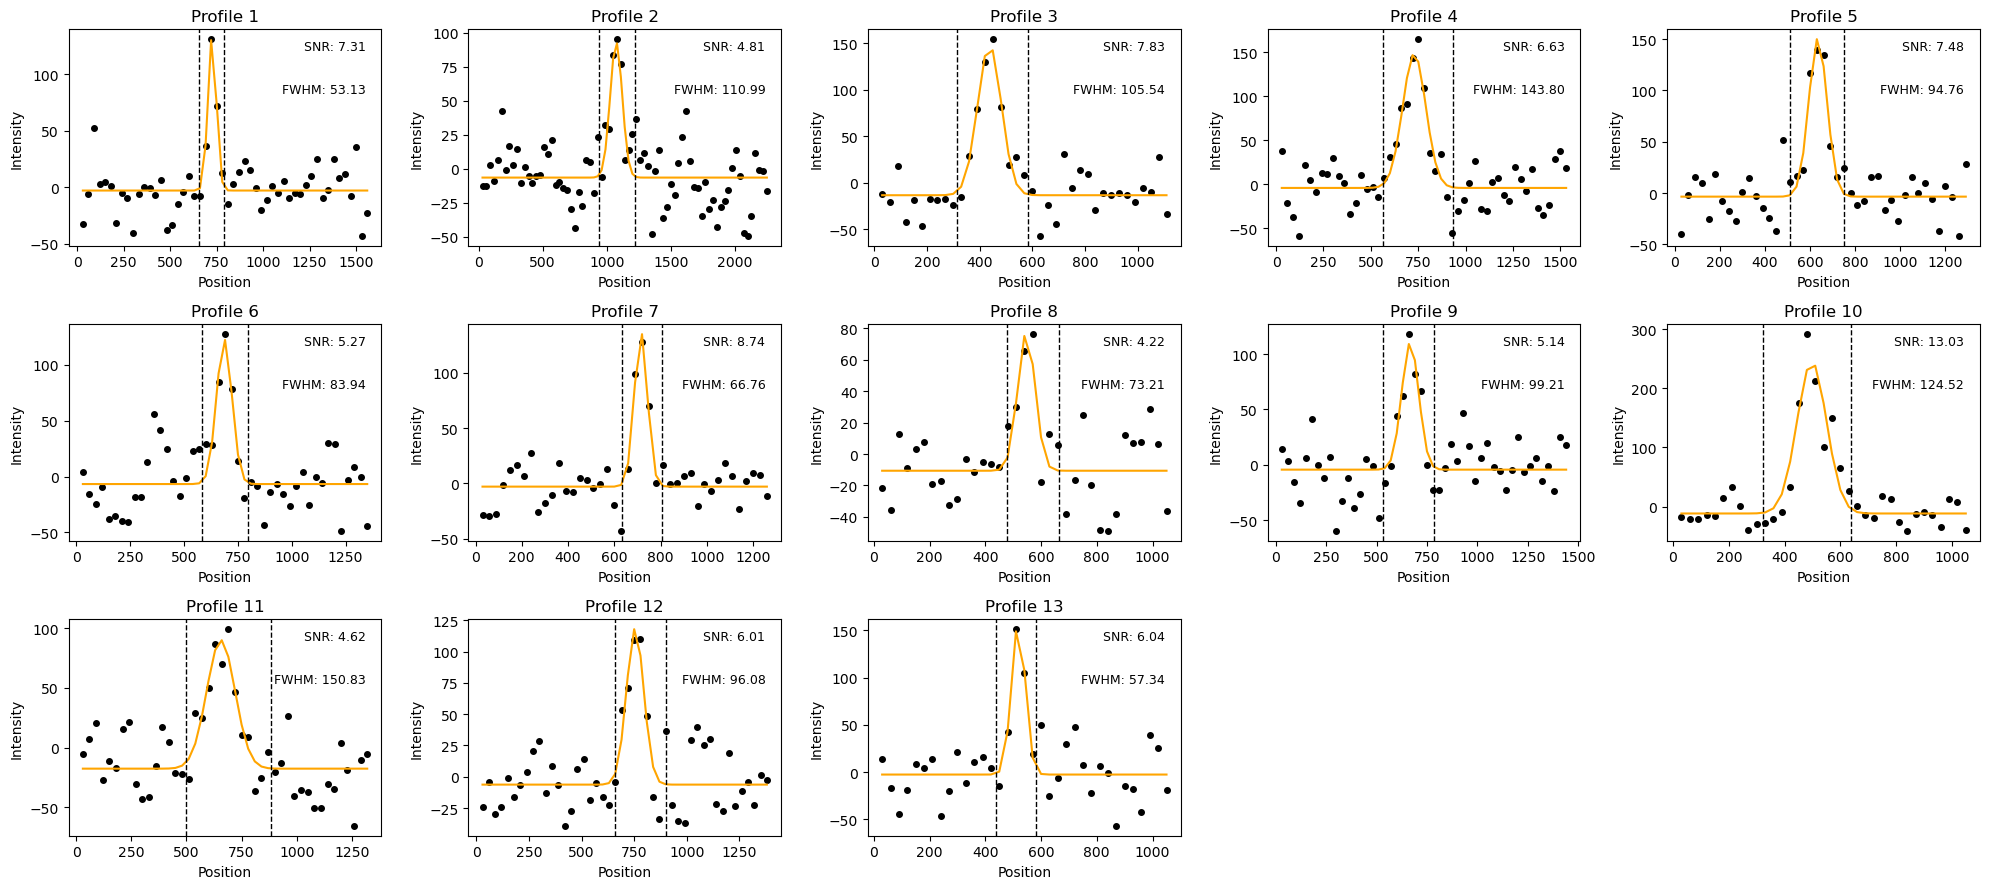

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq
import math

def single_gaussian(x, params):
    (c1, mu1, sigma1, cste) = params
    return c1 * np.exp(- (x - mu1) ** 2.0 / (2.0 * sigma1 ** 2.0)) + cste

def single_gaussian_fit(params, x, y):
    fit = single_gaussian(x, params)
    return fit - y

# Prepare subplot grid
num_profiles = y.shape[0]
max_cols = 5
cols = min(max_cols, num_profiles)
rows = math.ceil(num_profiles / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()  # Flatten to easily index even if it's 1D

for i in range(num_profiles):
    ax = axes[i]

    # Remove zero values from the profile
    y2 = y[i]
    mask = np.where(y2 != 0)
    y2 = y2[mask]
    x2 = x[mask]

    # Estimate initial parameters
    peak_pos = x2[np.argmax(y2)]
    max_value = np.max(y2)

    # Fit Gaussian
    fit = leastsq(single_gaussian_fit, [max_value, peak_pos, 80, 0], args=(x2, y2))
    params = fit[0][:4]  # [c1, mu1, sigma1, cste]

    # FWHM and SNR calculation
    sigma = params[2]
    fwhm = 2.35 * sigma
    bg_mask = (x2 < peak_pos - 3 * sigma) | (x2 > peak_pos + 3 * sigma)
    bg_y = y2[bg_mask]
    bg = np.std(bg_y) if len(bg_y) > 0 else np.nan  # avoid div by 0
    snr = params[0] / bg if bg != 0 and not np.isnan(bg) else np.nan

    # Plot data and fit
    ax.plot(x2, y2, 'ko', markersize=4, label='Data')
    ax.plot(x2, single_gaussian(x2, params), color='orange', label='Fit')

    # Plot background regions
    bg_left = peak_pos - 3 * sigma
    bg_right = peak_pos + 3 * sigma
    ax.axvline(bg_left, color='k', linestyle='--', linewidth=1)
    ax.axvline(bg_right, color='k', linestyle='--', linewidth=1)

    # Annotate SNR and FWHM
    ax.text(0.95, 0.95, f"SNR: {snr:.2f}", ha='right', va='top', transform=ax.transAxes, fontsize=9)
    ax.text(0.95, 0.75, f"FWHM: {fwhm:.2f}", ha='right', va='top', transform=ax.transAxes, fontsize=9)

    ax.set_title(f'Profile {i + 1}')
    ax.set_xlabel('Position')
    ax.set_ylabel('Intensity')
# Hide unused subplots
for j in range(num_profiles, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [1]:
def parse_clipboard_data(text):
    """
    Converts tabular text input (e.g. from copy-pasting) into x and y NumPy arrays.
    Assumes tab or space-separated two-column data.
    """
    # Split lines and filter out empty lines
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    # Split each line by whitespace or tab
    data = [list(map(float, line.split())) for line in lines]
    arr = np.array(data)
    x = arr[:, 0]
    y = arr[:, 1]
    return x, y

In [2]:
raw_data = """
0	21.0985
1	20.7581
2	21.4466
3	22.7656
4	26.0904
5	31.5952
6	41.8065
7	63.5435
8	85.2671
9	90.7693
10	78.2564
11	81.2270
12	99.1380
13	94.0381
14	66.2196
15	36.7633
16	25.7953
17	21.9763
18	20.6643
19	20.1656
"""

In [3]:
import numpy as np
x, y = parse_clipboard_data(raw_data)

In [4]:
import numpy as np
from scipy.optimize import leastsq

# params = [c1, mu1, sigma1, c2, mu2, sigma2]
x2 = np.linspace(min(x),max(x),100)

def single_gaussian(x,params):
    (c1, mu1, sigma1) = params
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) 
    return res
def double_gaussian(x, params):
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

def single_gaussian_fit(params,x,y):
    fit = single_gaussian(x, params)
    return (fit - y)

def double_gaussian_fit(params, x, y):
    fit = double_gaussian(x, params)
    return (fit - y)


# Least squares fit. 
fit = leastsq(double_gaussian_fit, [0.9,280,100,1,410,100], args=(x, y))

# Extract parameters for the Gaussians
params1 = fit[0][:3]  # [c1, mu1, sigma1]
params2 = fit[0][3:]  # [c2, mu2, sigma2]

# Calculate FWHM for each Gaussian
fwhm1 = 2.355 * params1[2]
fwhm2 = 2.355 * params2[2]

fig = plt.figure()

# Plot data and fitted Gaussians
plt.plot(x, y, 'ko', markersize=4)
plt.plot(x2, single_gaussian(x2, params1), 'orange')
plt.plot(x2, single_gaussian(x2, params2),'orange')
plt.plot(x2, double_gaussian(x2,fit[0]), 'k')

# Annotate FWHM on the plot
# plt.text(params1[1]-38, params1[0] / 2-0.1, f'{fwhm1:.0f}nm', color='b')
# plt.text(params2[1]-38, params2[0] / 2-0.1, f'{fwhm2:.0f}nm', color='g')


# Add double-sided arrows for FWHM
# plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
#              arrowprops=dict(arrowstyle='<->', color='b'))
# plt.annotate('', xy=(params2[1] - fwhm2 / 2, params2[0] / 2), xytext=(params2[1] + fwhm2 / 2, params2[0] / 2),
#              arrowprops=dict(arrowstyle='<->', color='g'))

# Show plot

plt.xlabel('x')
plt.ylabel('Normalized Intensity')
plt.show()


fig.savefig("lineProfile_mitoFast_18h30roi.svg", format="svg", bbox_inches='tight')


c:\Users\guillaume.minet\.conda\envs\dl_monalisa_1\lib\site-packages\scipy\optimize\_minpack_py.py:492: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  warnings.warn(errors[info][0], RuntimeWarning)


NameError: name 'plt' is not defined

In [37]:

print(params2[1]-params1[1])

143.40025075620622


In [ ]:
import csv
import matplotlib.pyplot as plt
import numpy as np
# Specify the path to your CSV file
csv_file_path = r'C:\Users\guillaume.minet\Documents\ValuesHDN.csv'
pxSize = 30
x = []
y = []

# Read data from the CSV file
with open(csv_file_path, 'r') as file:
    reader = csv.reader(file, delimiter=',')  # Use '\t' as the delimiter for tab-separated ys
    next(reader)  # Skip the first row (titles)
    for row in reader:
        # Assuming each row has two columns: index and y
        x.append(int(row[0]))
        y.append(float(row[1]))
x=np.stack(x) * pxSize
y=np.stack(y)
y = y - np.min(y)

plt.figure()
plt.plot(x,y)

In [ ]:
x2 = np.linspace(min(x),max(x),100)

# Least squares fit. 
fit = leastsq(single_gaussian_fit, [1.3,250,50], args=(x, y))

# Extract parameters for the Gaussians
params1 = fit[0]

# Calculate FWHM for each Gaussian
fwhm1 = 2.355 * params1[2]

# Plot data and fitted Gaussians
plt.plot(x, y, 'r--')
plt.plot(x2, single_gaussian(x2, params1), c='b')

# Annotate FWHM on the plot
plt.text(params1[1]-30, params1[0] / 2-0.1, f'{fwhm1:.0f}nm', color='b')

# Add double-sided arrows for FWHM
plt.annotate('', xy=(params1[1] - fwhm1 / 2, params1[0] / 2), xytext=(params1[1] + fwhm1 / 2, params1[0] / 2),
             arrowprops=dict(arrowstyle='<->', color='b'))

# Show plot
plt.xlabel('x')
plt.ylabel('Intensity')
plt.title('Double Gaussian Fit with FWHM')
plt.show()
